In [5]:
import cv2
import numpy as np
import types
import os
import matplotlib.pyplot as plt
os.chdir(r"D:\proj-python\Images_Vision")

In [6]:


def messageToBinary(message):

    if isinstance(message, str):
        return ''.join(format(ord(i), "08b") for i in message)

    elif isinstance(message, (bytes, np.ndarray)):
        return [format(i, "08b") for i in message]

    elif isinstance(message, (int, np.uint8)):
        return format(message, "08b")

    else:
        raise TypeError("Input type not supported")

In [7]:


def hideData(image, secret_message):

    n_bytes = image.shape[0] * image.shape[1] * 3 // 8

    print("Maximum number of bytes:", n_bytes)

    if len(secret_message) > n_bytes:
        raise ValueError("Error: secret message is too large for this image")

    index_data = 0

    secret_message += "###"

    binary_secret_message = messageToBinary(secret_message)

    data_length = len(binary_secret_message)

    for row in image:
        for pixel in row:

            b, g, r = messageToBinary(pixel)

            if index_data < data_length:
                pixel[0] = int(b[:-1] + binary_secret_message[index_data], 2)
                index_data += 1

            if index_data < data_length:
                pixel[1] = int(g[:-1] + binary_secret_message[index_data], 2)
                index_data += 1

            if index_data < data_length:
                pixel[2] = int(r[:-1] + binary_secret_message[index_data], 2)
                index_data += 1

            if index_data >= data_length:
                break

        if index_data >= data_length:
            break

    return image

In [8]:


def showData(image):
    binary_data = ""
    for row in image:
      for pixel in row:
        b,g,r=messageToBinary(pixel)
        binary_data += b[-1]
        binary_data += g[-1]
        binary_data += r[-1]
    all_bytes = [binary_data[i: i+8] for i in range(0, len(binary_data), 8)]
    decoded_data = ""
    for byte in all_bytes:
      decoded_data += chr(int(byte, 2))
      if decoded_data[-3:]=="###":
        break

    print(decoded_data)
    return decoded_data[:-3]
      

In [9]:
def saveDataInImage():
    image_name=input("Enter the name of the image: ")
    name=image_name
    image_name=str(image_name)+".jpg"
    
    image = cv2.imread(image_name)
    image=cv2.resize(image,(500,500))
    print("shape of image",image.shape)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.show()
    message=input("Enter the message to be hidden: ")
    new_image = hideData(image, message)
    cv2.imwrite("new_encrypted_"+name+".png", new_image)
    return new_image

In [10]:
def decode_text():
    image_name=input("Enter the name of the image: ")
    image_name="new_encrypted_"+str(image_name)+".png"
    image = cv2.imread(image_name)
    text = showData(image)
    text=showData(image)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title("Encrypted Image")
    plt.axis("off")
    plt.show()
    print("Decoded Text",text)
    return text

In [11]:
def Steganography():

    print("Welcome to Steganography")

    a = input("Image Steganography\n1. Encode Data\n2. Decode Data\n 3. quit from program")

    while True:

        if a == "1":
            print("Encoding...")
            saveDataInImage()
            break

        elif a == "2":
            print("Decoding...")
            decode_text()
            break
        elif a == "3":
            break

        else:
            print("Enter correct input")
            a = input("1. Encode Data\n2. Decode Data\n")

Welcome to Steganography
Encoding...
shape of image (500, 500, 3)


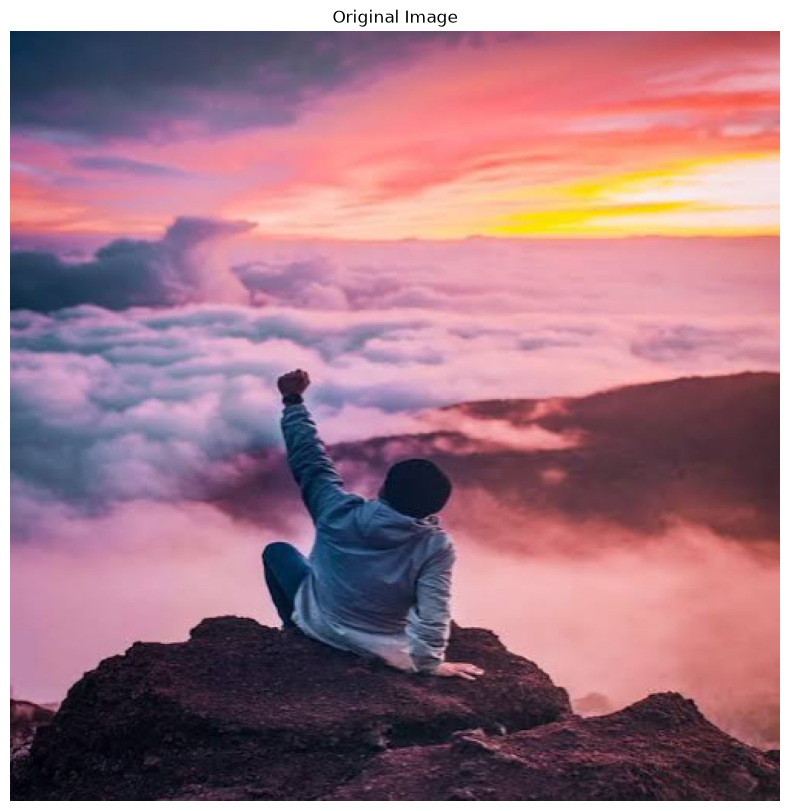

Maximum number of bytes: 93750


In [12]:

Steganography()

Welcome to Steganography
Decoding...
mohamed saleh###
mohamed saleh###


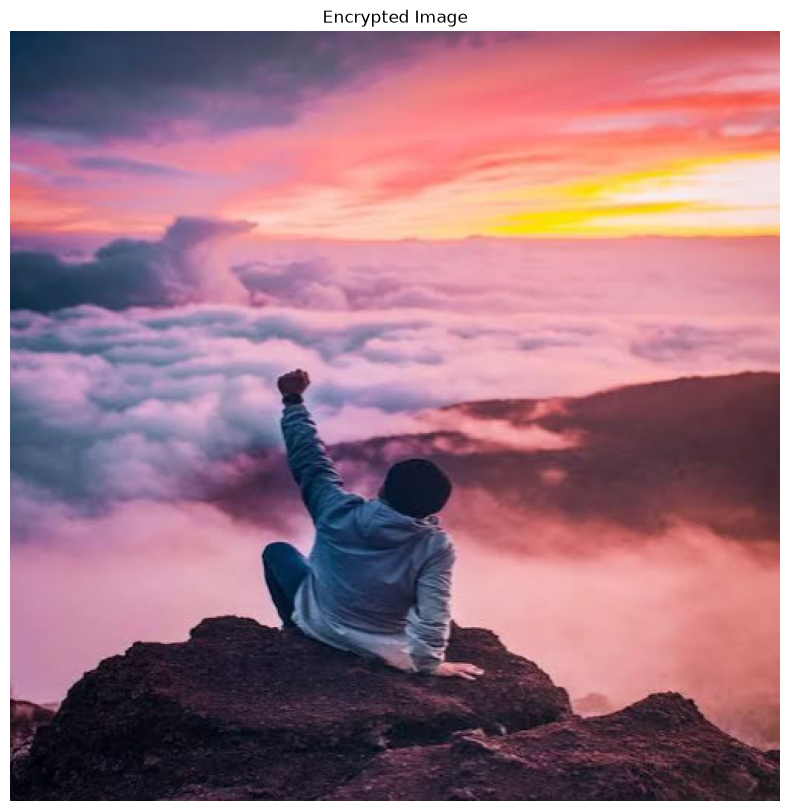

Decoded Text mohamed saleh


In [13]:
Steganography()

Welcome to Steganography
Encoding...
shape of image (500, 500, 3)


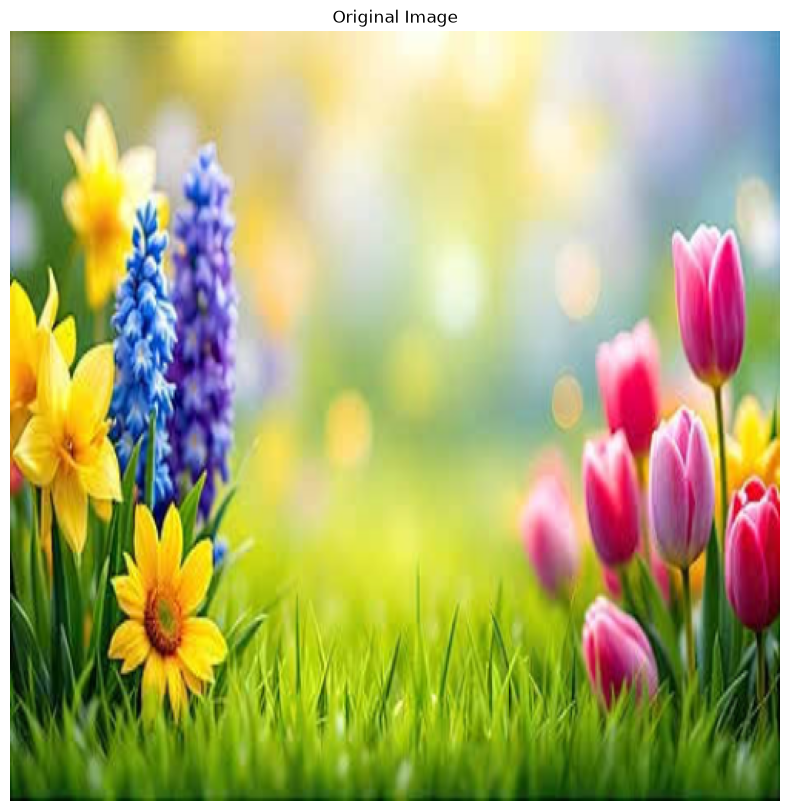

Maximum number of bytes: 93750


In [18]:
Steganography()

Welcome to Steganography
Decoding...
Steganography is an interesting technique that allows information to be hidden inside another type of digital media, such as an image. In this project, the secret message is converted into binary data, and the least significant bits of the image pixels are modified to store the hidden information. Because only the last bit of each color channel is changed, the visual appearance of the image remains almost identical to the original image. This experiment is useful for understanding how binary representation, pixel values, RGB or BGR color channels, ASCII characters, and lossless image formats work together in a practical computer vision application. The decoder reads the least significant bits from the encoded image, groups them into eight-bit binary values, converts those binary values into integers, and finally converts the integers into characters to reconstruct the original secret message. This message is intentionally long so that you can test w

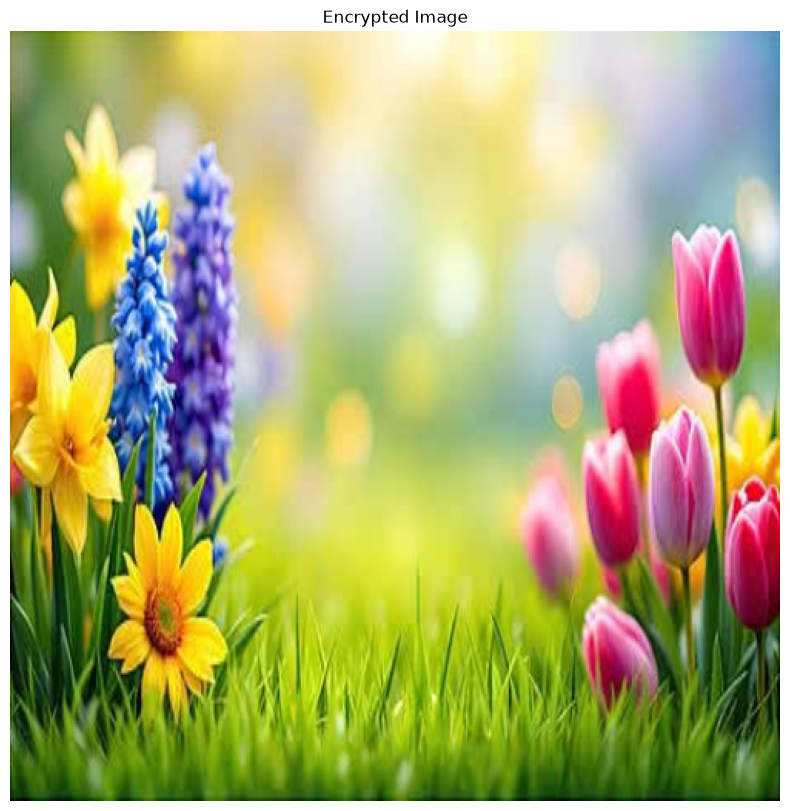

Decoded Text Steganography is an interesting technique that allows information to be hidden inside another type of digital media, such as an image. In this project, the secret message is converted into binary data, and the least significant bits of the image pixels are modified to store the hidden information. Because only the last bit of each color channel is changed, the visual appearance of the image remains almost identical to the original image. This experiment is useful for understanding how binary representation, pixel values, RGB or BGR color channels, ASCII characters, and lossless image formats work together in a practical computer vision application. The decoder reads the least significant bits from the encoded image, groups them into eight-bit binary values, converts those binary values into integers, and finally converts the integers into characters to reconstruct the original secret message. This message is intentionally long so that you can test whether your encoding and

In [19]:
Steganography()